# PanelOLS Demand Forecasting — Three Sector Models
**Thesis: Forecasting Electricity Demand in Europe to 2060**

Three Fixed Effects PanelOLS models:
- **Model 1**: Industrial demand (`demand_ind_TWh`)
- **Model 2**: Transport demand (`demand_tra_TWh`)
- **Model 3**: Other / Buildings demand (`demand_oth_TWh`)

**Data split:**
- Train: 1990–2014
- Backtest: 2015–2024
- Forecast: 2025–2060

**Specification (log-log where appropriate):**
```
ln(demand_it) = αᵢ + β₁·ln_pop + β₂·ln_gdp_pc + β₃·ln(1+HDD)
              + β₄·ln(1+CDD) + β₅·ln_industry_gva
              + β₆·ln_energy_intensity + β₇·eii_share + εᵢₜ
```
Note: Not all features are used in all models — see feature selection per model below.

In [12]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import jarque_bera, t as t_dist
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
print('Libraries loaded.')

Libraries loaded.


## 1. Load & Inspect Data

In [13]:
df = pd.read_csv('Data - raw/prepared_data/panel_transformed.csv')

print('Shape:', df.shape)
print('\nColumns:', list(df.columns))
print('\nYear range:', df['year'].min(), '–', df['year'].max())
print('Countries:', sorted(df['country'].unique()))
print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\nSample rows:')
df.head()

Shape: (1222, 19)

Columns: ['year', 'country', 'population_Mio', 'gdp_per_capita_USD', 'hdd_DegreesC', 'cdd_DegreesC', 'industry_va_MioEUR', 'energy_intensity_KGOE_per_EUR_PPS', 'eii_share_Percent', 'demand_ind_TWh', 'demand_tra_TWh', 'demand_oth_TWh', 'demand_tot_TWh', 'ln_gdp_pc', 'ln_pop', 'ln_industry_gva', 'ln_energy_intensity', 'ln_hdd', 'ln_cdd']

Year range: 1990 – 2060
Countries: ['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden']

Missing values:
demand_ind_TWh    312
demand_tra_TWh    312
demand_oth_TWh    312
demand_tot_TWh    312
dtype: int64

Sample rows:


,year,country,population_Mio,gdp_per_capita_USD,hdd_DegreesC,cdd_DegreesC,industry_va_MioEUR,energy_intensity_KGOE_per_EUR_PPS,eii_share_Percent,demand_ind_TWh,demand_tra_TWh,demand_oth_TWh,demand_tot_TWh,ln_gdp_pc,ln_pop,ln_industry_gva,ln_energy_intensity,ln_hdd,ln_cdd
0,1990,Austria,7.6448,43177.3541,3647.9486,25.6468,76647.3345,192.0274,21.7279,17.9800,2.7700,22.0170,42.7670,10.6731,2.1570,11.2470,5.2628,8.2022,3.2827
1,1990,Belgium,9.9478,41647.8132,2276.9519,46.2961,88330.3054,355.1891,32.9043,30.5230,1.2490,26.2120,57.9840,10.6370,2.3931,11.3888,5.8755,7.7310,3.8564
2,1990,Bulgaria,8.7673,13688.6850,2416.9632,129.4818,3161.4497,527.3737,17.5358,18.5520,1.3050,15.4150,35.2720,9.5244,2.2790,8.0591,6.2698,7.7907,4.8712
3,1990,Croatia,4.7726,17519.1014,1947.3455,106.4414,6163.8436,286.2601,13.4003,5.9840,0.3690,6.9500,13.3030,9.7711,1.7531,8.7266,5.6604,7.5747,4.6769
4,1990,Czechia,10.3621,30937.8173,3008.0336,32.2283,20501.5106,406.6609,32.2146,26.9220,3.1670,18.0880,48.1770,10.3398,2.4303,9.9283,6.0104,8.0094,3.5034


## 2. Prepare Features

Compute log-transformed target variables and the `ln(1+HDD)` / `ln(1+CDD)` transforms.
HDD/CDD use `ln(1+x)` to handle zero values safely (common in Nordic/Southern countries).

In [14]:
# ── Log-transform HDD/CDD safely (handles zeros) ─────────────────────────────
# already done in data preparation
#df['ln_hdd'] = np.log1p(df['hdd_DegreesC'])
#df['ln_cdd'] = np.log1p(df['cdd_DegreesC'])

# ── Log-transform targets (only for historical rows with actual values) ───────
for target in ['demand_ind_TWh', 'demand_tra_TWh', 'demand_oth_TWh']:
    df[f'ln_{target}'] = np.where(df[target] > 0, np.log(df[target]), np.nan)

# ── Split into historical and projection sets ─────────────────────────────────
hist = df[df['demand_ind_TWh'].notna()].copy()   # has actual demand values
proj = df[df['demand_ind_TWh'].isna()].copy()    # projection period (demand=NaN)

train    = hist[hist['year'] <= 2014].copy()
backtest = hist[hist['year'] >= 2015].copy()
forecast = proj.copy()

print(f"TRAIN    : {train.year.min()}–{train.year.max()}  ({len(train)} obs)")
print(f"BACKTEST : {backtest.year.min()}–{backtest.year.max()}  ({len(backtest)} obs)")
print(f"FORECAST : {forecast.year.min()}–{forecast.year.max()}  ({len(forecast)} obs)")

COUNTRIES = sorted(hist['country'].unique())
print(f"\nCountries ({len(COUNTRIES)}): {COUNTRIES}")

TRAIN    : 1990–2014  (650 obs)
BACKTEST : 2015–2024  (260 obs)
FORECAST : 2025–2060  (312 obs)

Countries (26): ['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden']


## 3. PanelOLS Engine

Manual within estimator (entity-demeaning) — identical to `linearmodels.PanelOLS` with `EntityEffects`.
Uses entity-clustered standard errors with small-sample correction.

In [15]:
def within_ols(train_df, target_col, feature_cols, entity_col='country'):
    """
    Fixed Effects OLS via within (entity-demeaning) transformation.
    Returns dict with: beta, se, t_stat, p_vals, r2_within, country_fe,
                       dw, jb_p, sigma2, features, target, entity_col
    """
    # Drop rows with any NaN in target or features
    cols = [entity_col, 'year', target_col] + feature_cols
    data = train_df[cols].dropna().copy()

    # ── Within transformation ─────────────────────────────────────────────────
    all_vars = [target_col] + feature_cols
    means    = data.groupby(entity_col)[all_vars].transform('mean')
    for col in all_vars:
        data[col + '_w'] = data[col] - means[col]

    Y = data[target_col + '_w'].values
    X = data[[f + '_w' for f in feature_cols]].values
    N, K = X.shape
    n_ent = data[entity_col].nunique()

    # ── OLS ───────────────────────────────────────────────────────────────────
    XtX  = X.T @ X
    beta = np.linalg.solve(XtX, X.T @ Y)
    resid = Y - X @ beta
    dof  = N - K - (n_ent - 1)

    # ── Entity-clustered SEs ─────────────────────────────────────────────────
    entities = data[entity_col].values
    meat = np.zeros((K, K))
    for c in np.unique(entities):
        idx = entities == c
        sc  = X[idx].T @ resid[idx]
        meat += np.outer(sc, sc)

    G      = n_ent
    bread  = np.linalg.inv(XtX)
    factor = (G / (G - 1)) * (N - 1) / (N - K)
    V      = factor * (bread @ meat @ bread)
    se     = np.sqrt(np.diag(V))
    t_stat = beta / se
    p_vals = 2 * (1 - t_dist.cdf(np.abs(t_stat), df=G - 1))

    # ── R² within ────────────────────────────────────────────────────────────
    ss_res = resid @ resid
    ss_tot = ((Y - Y.mean()) ** 2).sum()
    r2_within = 1 - ss_res / ss_tot

    # ── Country fixed effects (intercepts) ───────────────────────────────────
    data['xb'] = X @ beta
    country_fe = (data.groupby(entity_col)[target_col].mean()
                  - data.groupby(entity_col)['xb'].mean())

    # ── Diagnostics ──────────────────────────────────────────────────────────
    dw    = (np.diff(resid) ** 2).sum() / (resid ** 2).sum()
    _, jb_p = jarque_bera(resid)

    return {
        'beta'      : beta,
        'se'        : se,
        't_stat'    : t_stat,
        'p_vals'    : p_vals,
        'r2_within' : r2_within,
        'country_fe': country_fe,
        'dw'        : dw,
        'jb_p'      : jb_p,
        'n_obs'     : N,
        'n_ent'     : n_ent,
        'dof'       : dof,
        'features'  : feature_cols,
        'target'    : target_col,
        'entity_col': entity_col,
        'resid'     : resid,
        'data_used' : data,
    }


def predict_panel(model, df_in):
    """
    Apply fitted model to any DataFrame. Returns df_in with
    'pred_log' (prediction in log space) and 'pred_TWh' (level).
    Rows with missing features get NaN prediction.
    """
    d = df_in.copy()
    feat_cols = model['features']
    beta      = model['beta']
    fe        = model['country_fe']
    entity    = model['entity_col']

    d['xb']         = d[feat_cols].values @ beta
    d['country_fe'] = d[entity].map(fe)
    d['pred_log']   = d['xb'] + d['country_fe']
    d['pred_TWh']   = np.exp(d['pred_log'])
    return d


def print_model_summary(m, model_name):
    """Print a clean regression table."""
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    print(f"  Dependent var : {m['target']}")
    print(f"  N obs         : {m['n_obs']}  |  Entities: {m['n_ent']}  |  dof: {m['dof']}")
    print(f"  R² (within)   : {m['r2_within']:.4f}")
    print(f"  Durbin-Watson : {m['dw']:.4f}  {'✓' if 1.5 < m['dw'] < 2.5 else '⚠ autocorrelation'}")
    print(f"  Jarque-Bera p : {m['jb_p']:.4f}  {'✓ normal' if m['jb_p'] > 0.05 else '⚠ non-normal'}")
    print()
    print(f"  {'Variable':<25} {'Coef':>8}  {'SE':>8}  {'t':>7}  {'p':>7}  Sig")
    print(f"  {'-'*65}")
    for name, b, s, t_s, p in zip(
        m['features'], m['beta'], m['se'], m['t_stat'], m['p_vals']
    ):
        stars = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
        print(f"  {name:<25} {b:>8.4f}  {s:>8.4f}  {t_s:>7.2f}  {p:>7.4f}  {stars}")
    print(f"\n  Country Fixed Effects:")
    print(m['country_fe'].round(4).to_string())


def backtest_mape(model, backtest_df, actual_col):
    """Compute MAPE per country and overall for the backtest period."""
    bt = predict_panel(model, backtest_df)
    bt = bt.dropna(subset=[actual_col, 'pred_TWh'])
    bt['ape'] = np.abs(bt['pred_TWh'] - bt[actual_col]) / bt[actual_col] * 100
    overall   = bt['ape'].mean()
    by_country = bt.groupby('country')['ape'].mean().sort_values()
    return overall, by_country, bt


print('PanelOLS engine ready.')

PanelOLS engine ready.


## 4. Feature Specifications per Model

Economic logic for feature selection:
- **Industrial**: driven by economic output (GDP, industry GVA), efficiency, and energy-intensity of the industrial mix → no HDD/CDD, no transport features
- **Transport**: driven by economic activity, population (mobility), and GDP per capita. EVs not included (data sparse pre-2010) → minimal climate features  
- **Other/Buildings**: driven by all climate (heating/cooling), income, population → full feature set including HDD/CDD

In [16]:
# Feature sets per model
# Adjust if any column name differs from your actual CSV

FEATURES = {
    'demand_ind_TWh': [
        'ln_gdp_pc',           # income / economic activity level
        'ln_pop',              # scale
        'ln_industry_gva',     # structural: industrial output level
        'eii_share_Percent',           # structural: energy-intensive industry composition
        'ln_energy_intensity', # efficiency trend
    ],

    'demand_tra_TWh': [
        'ln_gdp_pc',           # income → car ownership, mobility
        'ln_pop',              # scale
        # Note: HDD/CDD excluded — climate has minimal effect on transport demand
        # Note: industry GVA excluded — transport demand driven by total economic activity
    ],

    'demand_oth_TWh': [
        'ln_gdp_pc',           # income → appliances, services, commercial activity
        'ln_pop',              # scale
        'ln_hdd',              # heating demand (buildings)
        'ln_cdd',              # cooling demand (buildings/services)
        'ln_energy_intensity', # efficiency trend (appliances, building standards)
    ],
}

TARGETS = list(FEATURES.keys())
LOG_TARGETS = {t: f'ln_{t}' for t in TARGETS}

print('Feature specifications:')
for target, feats in FEATURES.items():
    print(f'  {target}: {feats}')

Feature specifications:
  demand_ind_TWh: ['ln_gdp_pc', 'ln_pop', 'ln_industry_gva', 'eii_share_Percent', 'ln_energy_intensity']
  demand_tra_TWh: ['ln_gdp_pc', 'ln_pop']
  demand_oth_TWh: ['ln_gdp_pc', 'ln_pop', 'ln_hdd', 'ln_cdd', 'ln_energy_intensity']


## 5. Fit All Three Models

In [17]:
models = {}

for target in TARGETS:
    log_target = LOG_TARGETS[target]
    feats      = FEATURES[target]

    print(f"\nFitting model for: {target}")

    m = within_ols(
        train_df     = train,
        target_col   = log_target,
        feature_cols = feats,
    )
    models[target] = m

    print_model_summary(m, f'Model: ln({target})')

    # VIF check
    print(f"\n  VIF Check:")
    X_raw = train[feats].dropna().values
    for i, f in enumerate(feats):
        Xi = X_raw[:, i]
        Xj = np.delete(X_raw, i, axis=1)
        b  = np.linalg.lstsq(np.c_[np.ones(len(Xj)), Xj], Xi, rcond=None)[0]
        fit = np.c_[np.ones(len(Xj)), Xj] @ b
        r2  = 1 - ((Xi - fit)**2).sum() / ((Xi - Xi.mean())**2).sum()
        vif = 1 / (1 - r2) if r2 < 1 else np.inf
        flag = '⚠ HIGH' if vif > 10 else '✓'
        print(f"    {f:<25}  VIF = {vif:.2f}  {flag}")


Fitting model for: demand_ind_TWh

  Model: ln(demand_ind_TWh)
  Dependent var : ln_demand_ind_TWh
  N obs         : 650  |  Entities: 26  |  dof: 620
  R² (within)   : 0.3955
  Durbin-Watson : 1.7076  ✓
  Jarque-Bera p : 0.0000  ⚠ non-normal

  Variable                      Coef        SE        t        p  Sig
  -----------------------------------------------------------------
  ln_gdp_pc                   1.0690    0.1098     9.74   0.0000  ***
  ln_pop                      1.4712    0.3033     4.85   0.0001  ***
  ln_industry_gva            -0.0940    0.0670    -1.40   0.1729  
  eii_share_Percent          -0.0046    0.0038    -1.21   0.2372  
  ln_energy_intensity         0.5060    0.0808     6.26   0.0000  ***

  Country Fixed Effects:
country
Austria       3.0843
Belgium       3.6089
Bulgaria      2.3128
Croatia       1.1900
Czechia       3.0410
Denmark       2.2257
Estonia       0.7167
Finland       3.6717
France        4.8331
Germany       5.3868
Greece        2.5722
Hungary 

## 6. Backtest MAPE (2015–2024)

In [18]:
backtest_results = {}

print(f"{'Model':<25} {'Overall MAPE':>14}")
print('-' * 42)

for target in TARGETS:
    m       = models[target]
    overall, by_country, bt_df = backtest_mape(m, backtest, target)
    backtest_results[target]   = (overall, by_country, bt_df)
    print(f"  {target:<23} {overall:>12.2f}%")

print()
print('MAPE by country:')
for target in TARGETS:
    overall, by_country, _ = backtest_results[target]
    print(f"\n  {target}:")
    print(by_country.round(2).to_string())

Model                       Overall MAPE
------------------------------------------
  demand_ind_TWh          3208136484.46%
  demand_tra_TWh            5509348.92%
  demand_oth_TWh          292572182.87%

MAPE by country:

  demand_ind_TWh:
country
Latvia          145225645.8900
Estonia         146654283.8700
Slovenia        185533249.8300
Lithuania       193859946.9200
Luxembourg      242428374.0300
Croatia         273740421.8200
Slovakia        465082516.5800
Hungary         514705927.7700
Bulgaria        574755096.0800
Ireland         637453522.3000
Denmark         734885645.5300
Finland         831275252.2300
Portugal        862850886.4900
Norway          935526852.8300
Austria         947806446.3700
Greece          971228731.7800
Czechia        1191755238.8900
Sweden         1813714188.5600
Belgium        1838289981.4900
Romania        2176403985.9600
Netherlands    3646894389.8800
Poland         4277301992.9400
Spain          8162341559.0600
Italy         12190798635.4100
France

## 7. Generate Full Predictions (1990–2060)
Combine in-sample fitted values + backtest predictions + forecast

In [19]:
all_predictions = {}

for target in TARGETS:
    m = models[target]

    # Predict on each split
    train_p    = predict_panel(m, train)
    backtest_p = predict_panel(m, backtest)
    forecast_p = predict_panel(m, forecast)

    # Combine all periods
    combined = pd.concat([
        train_p[['country', 'year', target, 'pred_TWh']].assign(period='train'),
        backtest_p[['country', 'year', target, 'pred_TWh']].assign(period='backtest'),
        forecast_p[['country', 'year', 'pred_TWh']].assign(**{target: np.nan}, period='forecast'),
    ], ignore_index=True)

    all_predictions[target] = combined
    print(f"  {target}: {len(combined)} total rows combined")

print('\nPredictions ready.')

  demand_ind_TWh: 1222 total rows combined
  demand_tra_TWh: 1222 total rows combined
  demand_oth_TWh: 1222 total rows combined

Predictions ready.


## 8. Residual Diagnostics Plots

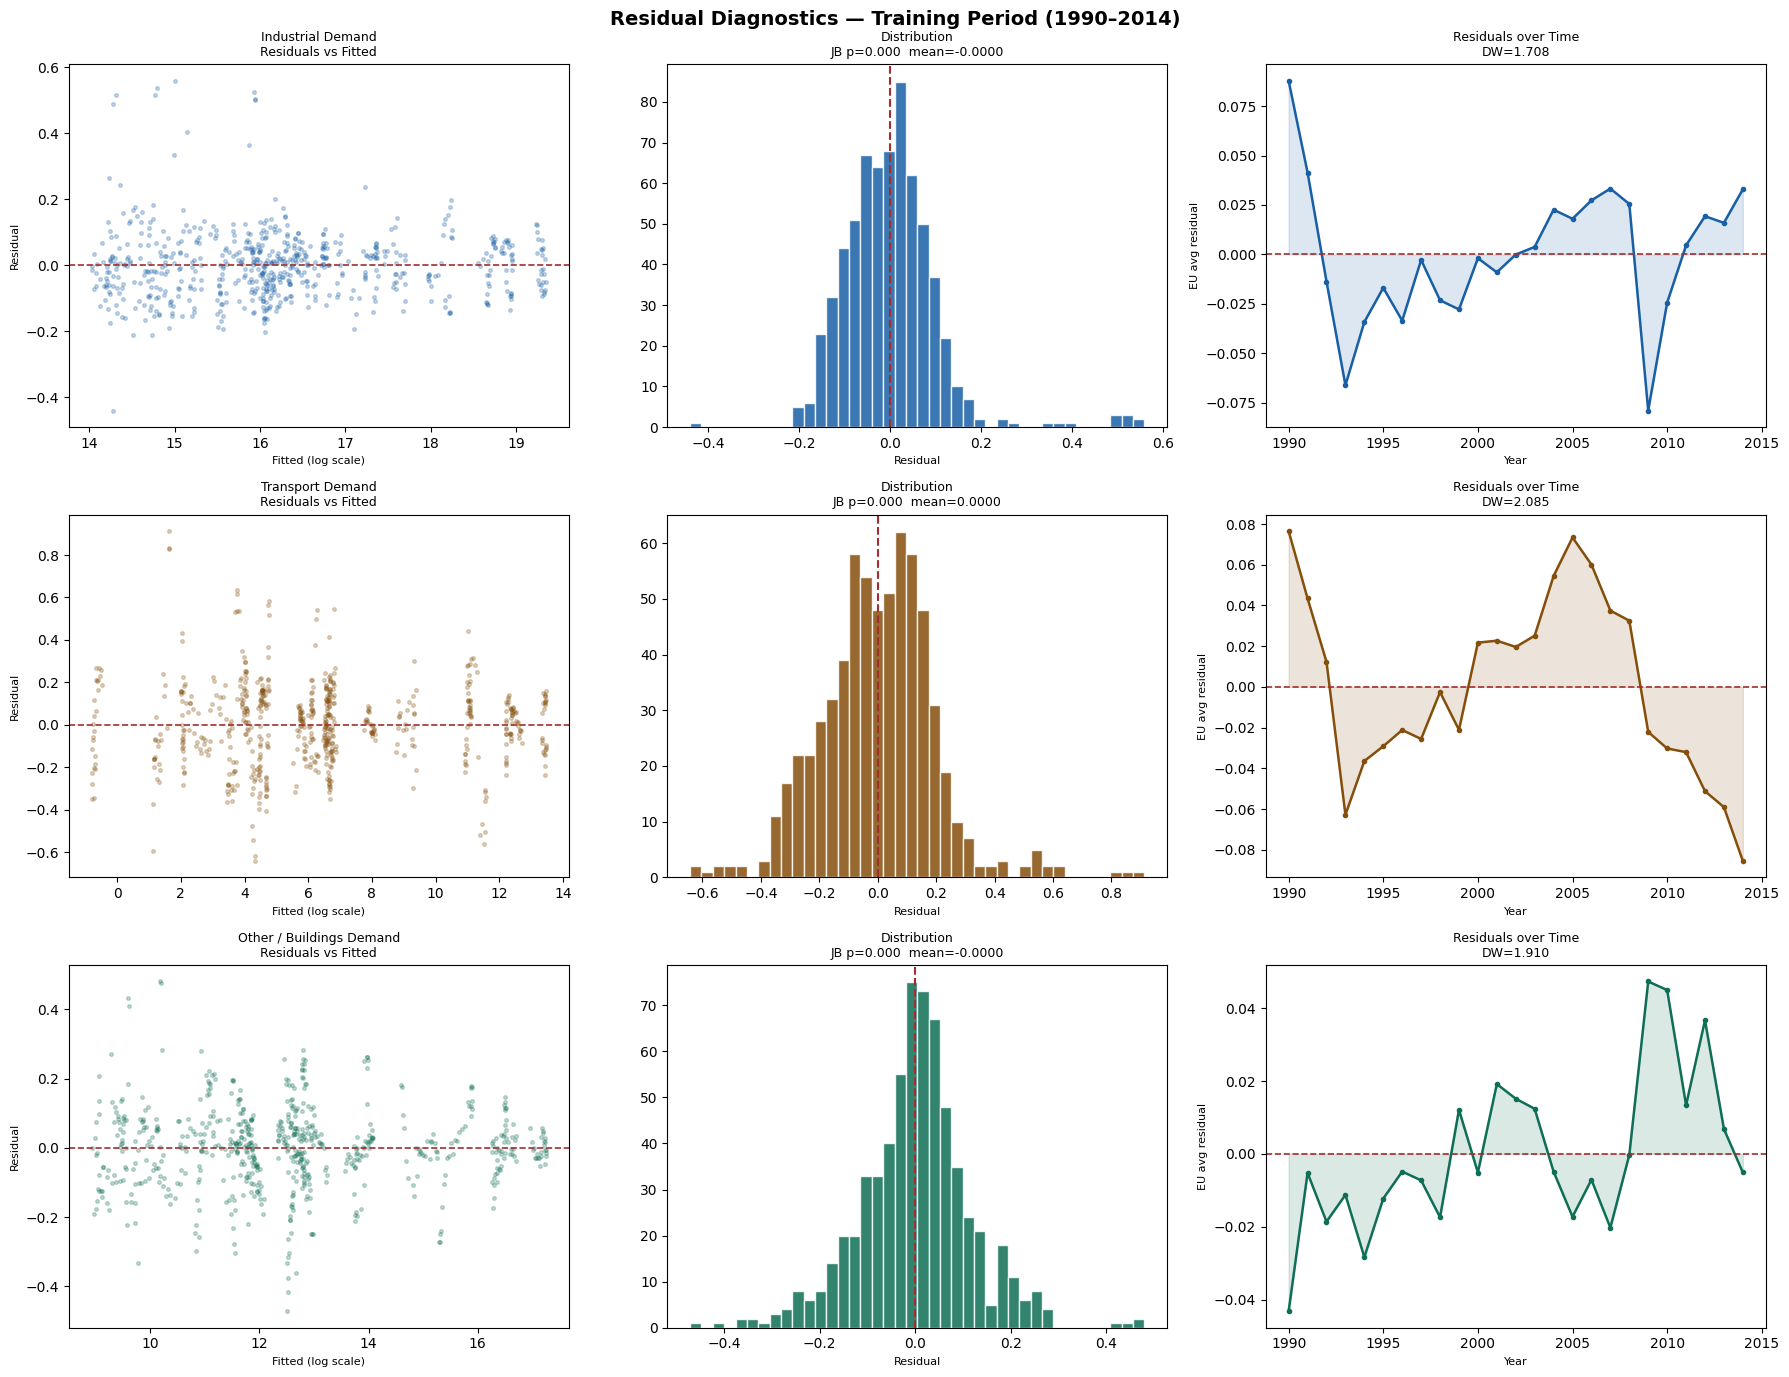

Saved: fig_diagnostics_all_models.png


In [20]:
C = {
    'train'   : '#185FA5',
    'back'    : '#854F0B',
    'fore'    : '#0F6E56',
    'actual'  : '#2C2C2A',
    'red'     : '#A32D2D',
    'amber'   : '#EF9F27',
}

MODEL_LABELS = {
    'demand_ind_TWh': 'Industrial Demand',
    'demand_tra_TWh': 'Transport Demand',
    'demand_oth_TWh': 'Other / Buildings Demand',
}

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Residual Diagnostics — Training Period (1990–2014)', fontsize=14, fontweight='bold')

for row_idx, target in enumerate(TARGETS):
    m     = models[target]
    resid = m['resid']
    data  = m['data_used']
    label = MODEL_LABELS[target]
    color = [C['train'], C['back'], C['fore']][row_idx]

    # Residuals vs fitted
    ax0 = axes[row_idx][0]
    fitted = data[m['features']].values @ m['beta']
    ax0.scatter(fitted, resid, alpha=0.25, s=7, color=color)
    ax0.axhline(0, color=C['red'], lw=1.2, ls='--')
    ax0.set_title(f'{label}\nResiduals vs Fitted', fontsize=9)
    ax0.set_xlabel('Fitted (log scale)', fontsize=8)
    ax0.set_ylabel('Residual', fontsize=8)

    # Residual histogram
    ax1 = axes[row_idx][1]
    ax1.hist(resid, bins=40, color=color, alpha=0.85, edgecolor='white')
    ax1.axvline(0, color=C['red'], lw=1.5, ls='--')
    ax1.set_title(f'Distribution\nJB p={m["jb_p"]:.3f}  mean={resid.mean():.4f}', fontsize=9)
    ax1.set_xlabel('Residual', fontsize=8)

    # Residuals over time (EU mean)
    ax2 = axes[row_idx][2]
    data_copy = data.copy()
    data_copy['resid'] = resid
    rby = data_copy.groupby('year')['resid'].mean()
    ax2.plot(rby.index, rby.values, color=color, lw=1.8, marker='o', ms=3)
    ax2.axhline(0, color=C['red'], lw=1.2, ls='--')
    ax2.fill_between(rby.index, rby.values, 0, alpha=0.15, color=color)
    ax2.set_title(f'Residuals over Time\nDW={m["dw"]:.3f}', fontsize=9)
    ax2.set_xlabel('Year', fontsize=8)
    ax2.set_ylabel('EU avg residual', fontsize=8)

plt.tight_layout()
plt.savefig('fig_diagnostics_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_diagnostics_all_models.png')

## 9. MAPE Bar Charts — Backtest Comparison

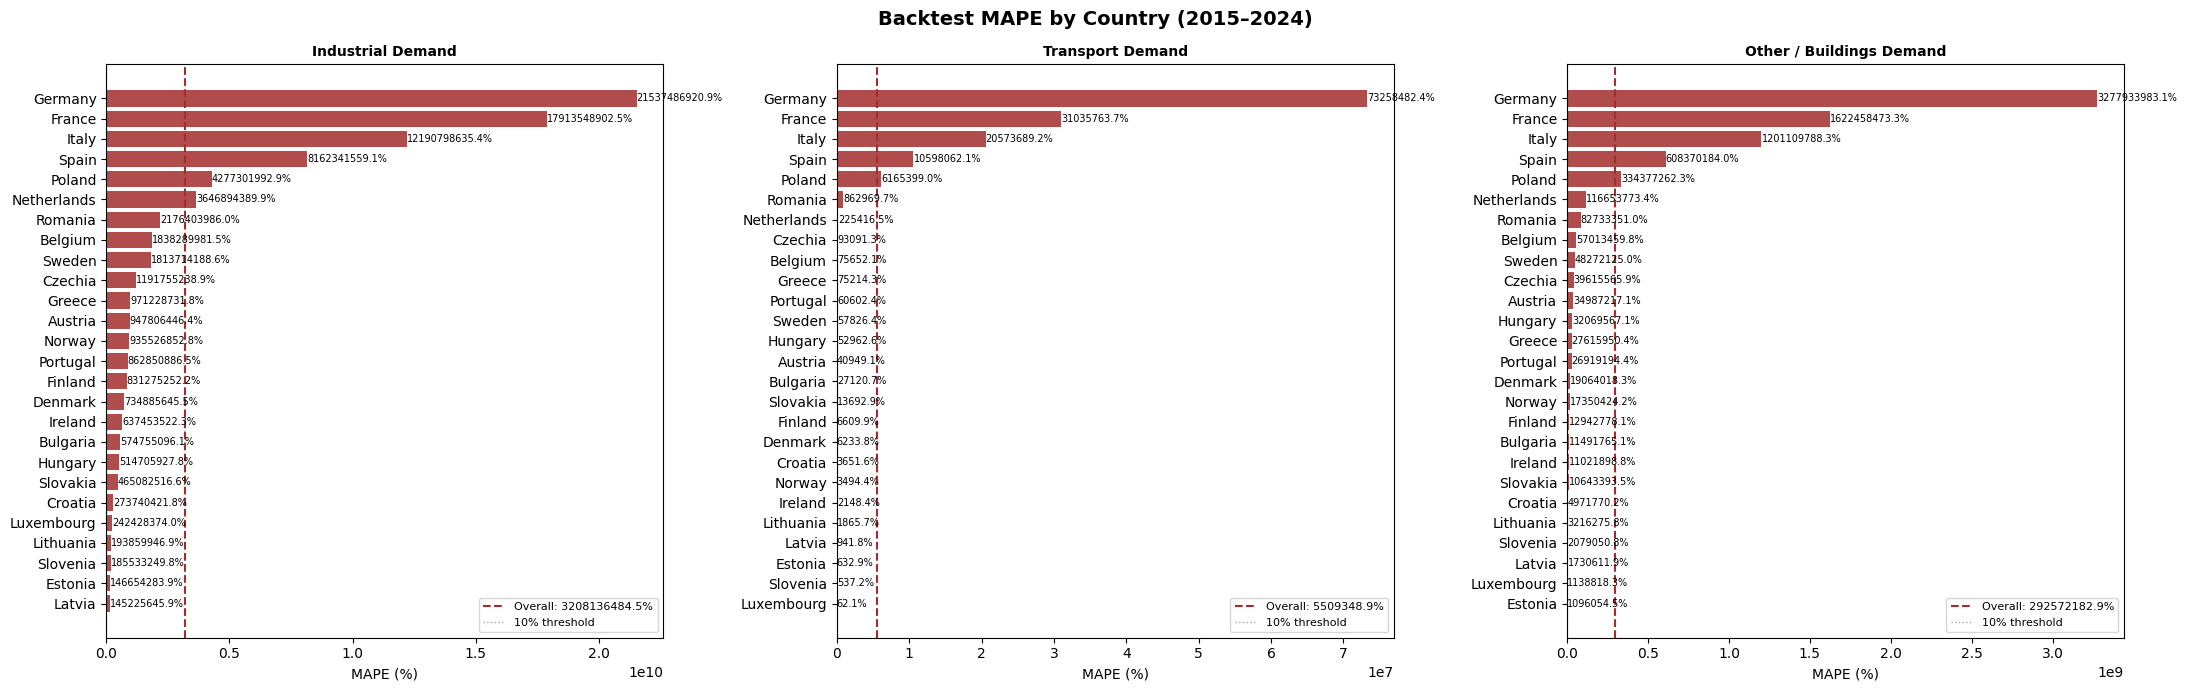

Saved: fig_mape_backtest.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Backtest MAPE by Country (2015–2024)', fontsize=14, fontweight='bold')

for ax, target in zip(axes, TARGETS):
    overall, by_country, _ = backtest_results[target]

    bar_colors = [
        C['fore'] if v <= 5 else (C['amber'] if v <= 15 else C['red'])
        for v in by_country.values
    ]
    bars = ax.barh(by_country.index, by_country.values, color=bar_colors, alpha=0.85)

    ax.axvline(overall, color=C['red'], ls='--', lw=1.5,
               label=f'Overall: {overall:.1f}%')
    ax.axvline(10, color='gray', ls=':', lw=1, alpha=0.7, label='10% threshold')

    for bar, val in zip(bars, by_country.values):
        ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=7)

    ax.set_title(MODEL_LABELS[target], fontsize=10, fontweight='bold')
    ax.set_xlabel('MAPE (%)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_mape_backtest.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_mape_backtest.png')

## 10. Per-Country Time Series — All Three Models

For each country: actual historical + fitted (train) + backtest + forecast,
for all three demand sectors side by side.

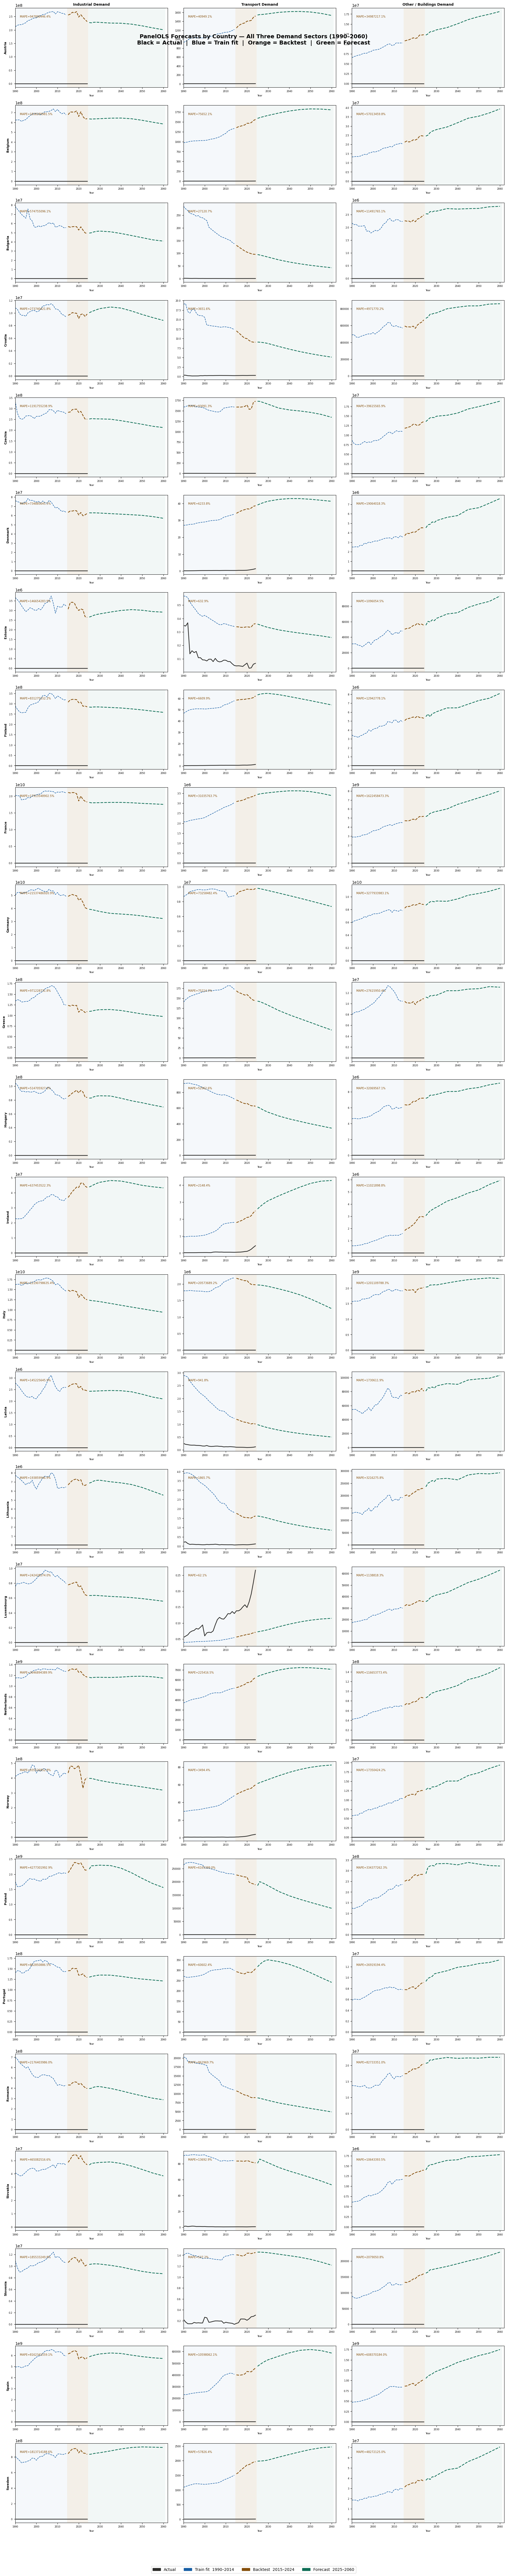

Saved: fig_per_country_all_sectors.png


In [22]:
n_countries = len(COUNTRIES)
n_models    = len(TARGETS)

fig, axes = plt.subplots(
    n_countries, n_models,
    figsize=(n_models * 6, n_countries * 3.5),
    sharex=False
)

fig.suptitle(
    'PanelOLS Forecasts by Country — All Three Demand Sectors (1990–2060)\n'
    'Black = Actual  |  Blue = Train fit  |  Orange = Backtest  |  Green = Forecast',
    fontsize=14, fontweight='bold'
)

for row_idx, country in enumerate(COUNTRIES):
    for col_idx, target in enumerate(TARGETS):

        ax = axes[row_idx][col_idx]
        pred_df = all_predictions[target]
        act_df  = hist

        # Split by period for this country
        tr = pred_df[(pred_df['country'] == country) & (pred_df['period'] == 'train')]
        bt = pred_df[(pred_df['country'] == country) & (pred_df['period'] == 'backtest')]
        fc = pred_df[(pred_df['country'] == country) & (pred_df['period'] == 'forecast')]
        ac = act_df[act_df['country'] == country]

        # Actual historical
        ax.plot(ac['year'], ac[target],
                color=C['actual'], lw=1.8, zorder=4, label='Actual')

        # Train fit
        ax.plot(tr['year'], tr['pred_TWh'],
                color=C['train'], lw=1.2, ls='--', zorder=2, label='Train fit')

        # Backtest
        ax.plot(bt['year'], bt['pred_TWh'],
                color=C['back'], lw=1.8, ls='--', zorder=5, label='Backtest')

        # Forecast
        ax.plot(fc['year'], fc['pred_TWh'],
                color=C['fore'], lw=1.8, ls='--', zorder=3, label='Forecast')

        # Shade periods
        ax.axvspan(1990, 2014.5, alpha=0.04, color=C['train'], lw=0)
        ax.axvspan(2014.5, 2024.5, alpha=0.09, color=C['back'], lw=0)
        ax.axvspan(2024.5, 2061, alpha=0.05, color=C['fore'], lw=0)

        # MAPE annotation
        _, by_c, _ = backtest_results[target]
        mape_val   = by_c.get(country, float('nan'))

        # Title: country name on leftmost column only, sector label on top row only
        if col_idx == 0:
            ax.set_ylabel(country, fontsize=8, fontweight='bold')
        if row_idx == 0:
            ax.set_title(MODEL_LABELS[target], fontsize=9, fontweight='bold')

        ax.annotate(f'MAPE={mape_val:.1f}%',
                    xy=(0.03, 0.88), xycoords='axes fraction',
                    fontsize=7, color=C['back'])

        ax.set_xlim(1990, 2062)
        ax.tick_params(labelsize=6)
        ax.set_xlabel('Year', fontsize=6)

# Single shared legend at the bottom
legend_handles = [
    mpatches.Patch(color=C['actual'], label='Actual'),
    mpatches.Patch(color=C['train'],  label='Train fit  1990–2014'),
    mpatches.Patch(color=C['back'],   label='Backtest  2015–2024'),
    mpatches.Patch(color=C['fore'],   label='Forecast  2025–2060'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           fontsize=10, bbox_to_anchor=(0.5, -0.005))

plt.tight_layout(rect=[0, 0.01, 1, 1])
plt.savefig('fig_per_country_all_sectors.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: fig_per_country_all_sectors.png')

## 11. EU Aggregate Forecast — All Three Sectors

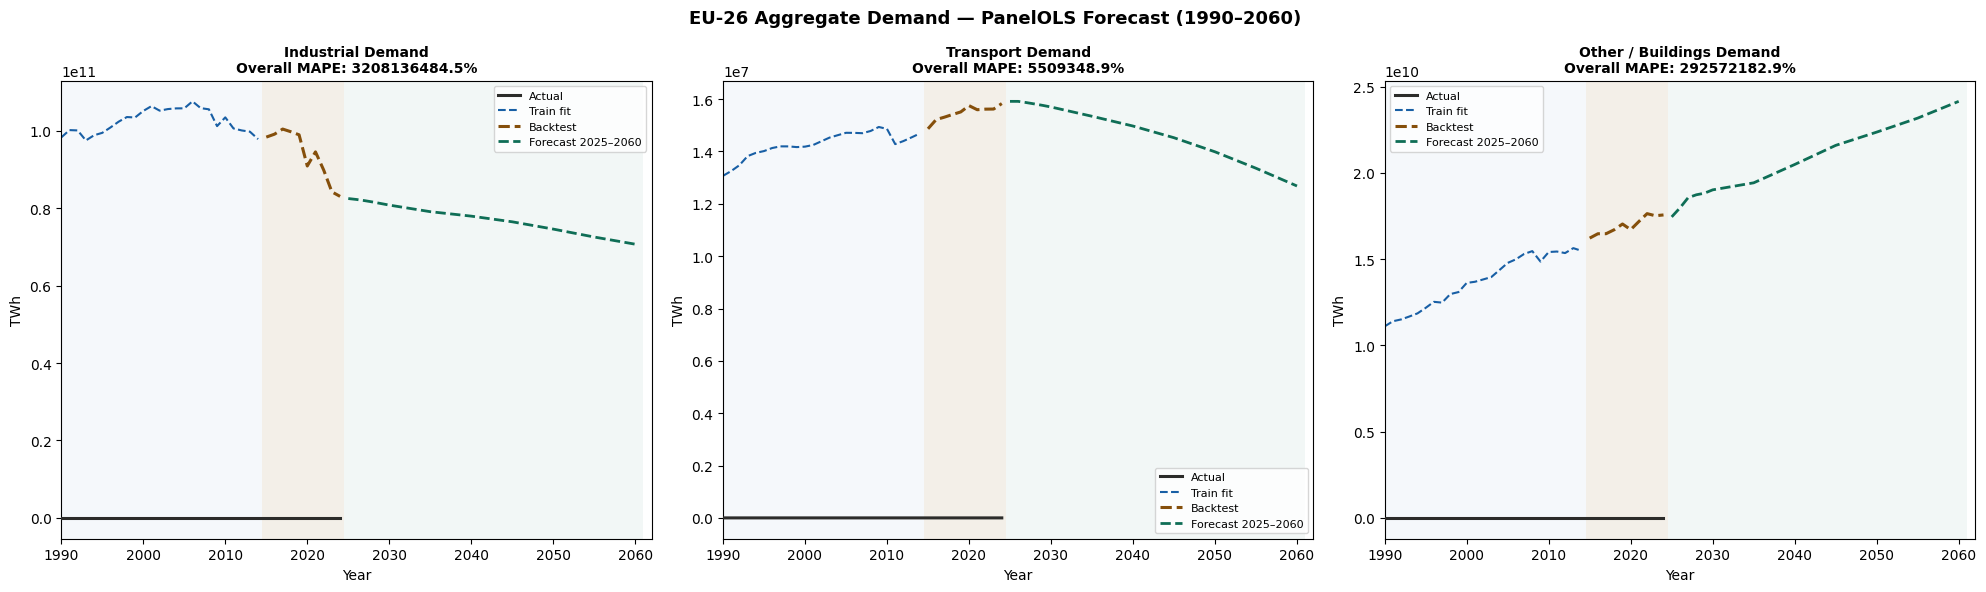

Saved: fig_eu_aggregate_all_sectors.png


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('EU-26 Aggregate Demand — PanelOLS Forecast (1990–2060)',
             fontsize=13, fontweight='bold')

for ax, target in zip(axes, TARGETS):
    pred_df = all_predictions[target]

    # EU aggregate by period
    eu_act = hist.groupby('year')[target].sum()
    eu_tr  = pred_df[pred_df['period'] == 'train'].groupby('year')['pred_TWh'].sum()
    eu_bt  = pred_df[pred_df['period'] == 'backtest'].groupby('year')['pred_TWh'].sum()
    eu_fc  = pred_df[pred_df['period'] == 'forecast'].groupby('year')['pred_TWh'].sum()

    overall, _, _ = backtest_results[target]

    ax.plot(eu_act.index, eu_act.values,
            color=C['actual'], lw=2.2, label='Actual', zorder=4)
    ax.plot(eu_tr.index, eu_tr.values,
            color=C['train'], lw=1.5, ls='--', label='Train fit')
    ax.plot(eu_bt.index, eu_bt.values,
            color=C['back'], lw=2.2, ls='--', label='Backtest', zorder=5)
    ax.plot(eu_fc.index, eu_fc.values,
            color=C['fore'], lw=2.0, ls='--', label='Forecast 2025–2060')

    ax.axvspan(1990, 2014.5, alpha=0.04, color=C['train'], lw=0)
    ax.axvspan(2014.5, 2024.5, alpha=0.09, color=C['back'], lw=0)
    ax.axvspan(2024.5, 2061, alpha=0.05, color=C['fore'], lw=0)

    ax.set_title(f'{MODEL_LABELS[target]}\nOverall MAPE: {overall:.1f}%',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('TWh')
    ax.legend(fontsize=8)
    ax.set_xlim(1990, 2062)

plt.tight_layout()
plt.savefig('fig_eu_aggregate_all_sectors.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_eu_aggregate_all_sectors.png')

## 12. Save Residuals for XGBoost Layer

In [24]:
# For each model, add OLS residuals and lagged residuals to training data
# This becomes the input for the XGBoost residual correction layer

residuals_combined = train[['country', 'year']].copy()

for target in TARGETS:
    m      = models[target]
    tr     = predict_panel(m, train).copy()
    log_t  = LOG_TARGETS[target]

    tr[f'ols_resid_{target}']  = tr[log_t] - tr['pred_log']
    tr[f'resid_lag1_{target}'] = tr.groupby('country')[f'ols_resid_{target}'].shift(1)
    tr[f'resid_lag2_{target}'] = tr.groupby('country')[f'ols_resid_{target}'].shift(2)

    cols = ['country', 'year',
            f'ols_resid_{target}',
            f'resid_lag1_{target}',
            f'resid_lag2_{target}']

    residuals_combined = residuals_combined.merge(
        tr[cols], on=['country', 'year'], how='left'
    )

# Also add original features for XGBoost input
all_feats = list(set(
    feat for feats in FEATURES.values() for feat in feats
))
train_full = train[['country', 'year'] + all_feats +
                   [f'ln_{t}' for t in TARGETS] + TARGETS].copy()
train_full = train_full.merge(residuals_combined, on=['country', 'year'], how='left')

train_full.to_csv('panel_with_ols_residuals.csv', index=False)
print(f'Saved: panel_with_ols_residuals.csv  shape={train_full.shape}')
print(f'Columns: {list(train_full.columns)}')
train_full.head()

Saved: panel_with_ols_residuals.csv  shape=(650, 24)
Columns: ['country', 'year', 'ln_energy_intensity', 'ln_industry_gva', 'ln_pop', 'ln_hdd', 'eii_share_Percent', 'ln_cdd', 'ln_gdp_pc', 'ln_demand_ind_TWh', 'ln_demand_tra_TWh', 'ln_demand_oth_TWh', 'demand_ind_TWh', 'demand_tra_TWh', 'demand_oth_TWh', 'ols_resid_demand_ind_TWh', 'resid_lag1_demand_ind_TWh', 'resid_lag2_demand_ind_TWh', 'ols_resid_demand_tra_TWh', 'resid_lag1_demand_tra_TWh', 'resid_lag2_demand_tra_TWh', 'ols_resid_demand_oth_TWh', 'resid_lag1_demand_oth_TWh', 'resid_lag2_demand_oth_TWh']


,country,year,ln_energy_intensity,ln_industry_gva,ln_pop,ln_hdd,eii_share_Percent,ln_cdd,ln_gdp_pc,ln_demand_ind_TWh,...,demand_oth_TWh,ols_resid_demand_ind_TWh,resid_lag1_demand_ind_TWh,resid_lag2_demand_ind_TWh,ols_resid_demand_tra_TWh,resid_lag1_demand_tra_TWh,resid_lag2_demand_tra_TWh,ols_resid_demand_oth_TWh,resid_lag1_demand_oth_TWh,resid_lag2_demand_oth_TWh
0,Austria,1990,5.2628,11.2470,2.1570,8.2022,21.7279,3.2827,10.6731,2.8893,...,22.0170,-16.2826,NaN,NaN,-5.8148,NaN,NaN,-12.5986,NaN,NaN
1,Belgium,1990,5.8755,11.3888,2.3931,7.7310,32.9043,3.8564,10.6370,3.4185,...,26.2120,-16.8319,NaN,NaN,-6.6575,NaN,NaN,-13.1262,NaN,NaN
2,Bulgaria,1990,6.2698,8.0591,2.2790,7.7907,17.5358,4.8712,9.5244,2.9206,...,15.4150,-15.2601,NaN,NaN,-5.3870,NaN,NaN,-11.8555,NaN,NaN
3,Croatia,1990,5.6604,8.7266,1.7531,7.5747,13.4003,4.6769,9.7711,1.7891,...,6.9500,-14.4067,NaN,NaN,-3.9438,NaN,NaN,-11.1606,NaN,NaN
4,Czechia,1990,6.0104,9.9283,2.4303,8.0094,32.2146,3.5034,10.3398,3.2929,...,18.0880,-16.3354,NaN,NaN,-6.2176,NaN,NaN,-13.0812,NaN,NaN


## 13. Save Full Predictions to CSV

In [25]:
# Combine predictions for all three models into one wide CSV
pred_wide = df[['country', 'year']].copy()

for target in TARGETS:
    pred_df = all_predictions[target][['country', 'year', 'pred_TWh', 'period']]
    pred_df = pred_df.rename(columns={'pred_TWh': f'pred_{target}',
                                       'period': f'period_{target}'})
    pred_wide = pred_wide.merge(pred_df, on=['country', 'year'], how='left')

# Add actual values
for target in TARGETS:
    pred_wide = pred_wide.merge(
        df[['country', 'year', target]],
        on=['country', 'year'], how='left'
    )

pred_wide = pred_wide.sort_values(['country', 'year']).reset_index(drop=True)
pred_wide.to_csv('ols_predictions_all_sectors.csv', index=False)

print(f'Saved: ols_predictions_all_sectors.csv  shape={pred_wide.shape}')
print(f'\nSample (Germany):')
pred_wide[pred_wide['country'] == 'Germany'].tail(10).to_string()

Saved: ols_predictions_all_sectors.csv  shape=(1222, 11)

Sample (Germany):


'     country  year  pred_demand_ind_TWh period_demand_ind_TWh  pred_demand_tra_TWh period_demand_tra_TWh  pred_demand_oth_TWh period_demand_oth_TWh  demand_ind_TWh  demand_tra_TWh  demand_oth_TWh\n460  Germany  2027     38695466059.3490              forecast         9697978.4528              forecast      9222048819.9967              forecast             NaN             NaN             NaN\n461  Germany  2028     38317087427.4404              forecast         9632607.4824              forecast      9287000358.0718              forecast             NaN             NaN             NaN\n462  Germany  2029     37923469553.2857              forecast         9568138.8787              forecast      9232908896.8944              forecast             NaN             NaN             NaN\n463  Germany  2030     37543156589.4885              forecast         9501959.9188              forecast      9347370163.2124              forecast             NaN             NaN             NaN\n464  Germany  

## Summary

| Output file | Contents |
|---|---|
| `panel_with_ols_residuals.csv` | Training data + OLS residuals + lags → XGBoost input |
| `ols_predictions_all_sectors.csv` | Predictions for all countries, all years, all three models |
| `fig_diagnostics_all_models.png` | Residual diagnostics (3×3 grid) |
| `fig_mape_backtest.png` | MAPE bar charts by country |
| `fig_per_country_all_sectors.png` | Per-country time series (all three sectors) |
| `fig_eu_aggregate_all_sectors.png` | EU-26 aggregate forecast |

**Next step:** feed `panel_with_ols_residuals.csv` into the XGBoost residual correction model.